# Teste funcionalidades

```{admonition} Teste tip
:class: tip

Conteúdo aqui

```{admonition} Teste note
:class: note

Conteúdo aqui

```{admonition} Teste warning
:class: warning

Conteúdo aqui

```{admonition} Teste dropdown
:class: dropdown

Conteúdo aqui

```{mermaid}
graph LR
R[Início] --> A[A]
R --> B[B]

A --> A1[1]
A --> A2[2]
A --> A3[3]

B --> B1[1]
B --> B2[2]
B --> B3[3]
```

````{tab-set}
```{tab-item} Tab 1 title
My first tab
```

```{tab-item} Tab 2 title
My second tab with `some code`!
```
````

In [2]:
%%html
<p><b>Sua resposta:</b></p>
<textarea style="width: 100%; height: 100px; border: 1px solid #ccc; border-radius: 4px;"></textarea>

In [1]:
from jupyterquiz import display_quiz

# Definição da pergunta
pergunta = [{
    "question": "Quantos números de 3 algarismos podem ser formados com os algarismos 1,2,3,4,5?",
    "type": "multiple_choice",
    "answers": [
        {"answer": "15", "correct": False, "feedback": "Não é isso! Pense em quantas escolhas você tem pra cada posição"},
        {"answer": "125", "correct": True, "feedback": "Exato! 5 possibilidades para cada posição! 5x5x5"},
        {"answer": "60", "correct": False, "feedback": "Não é isso! Lembre-se que os algarismos podem se repetir"}
    ]
}]

display_quiz(pergunta)

<IPython.core.display.Javascript object>

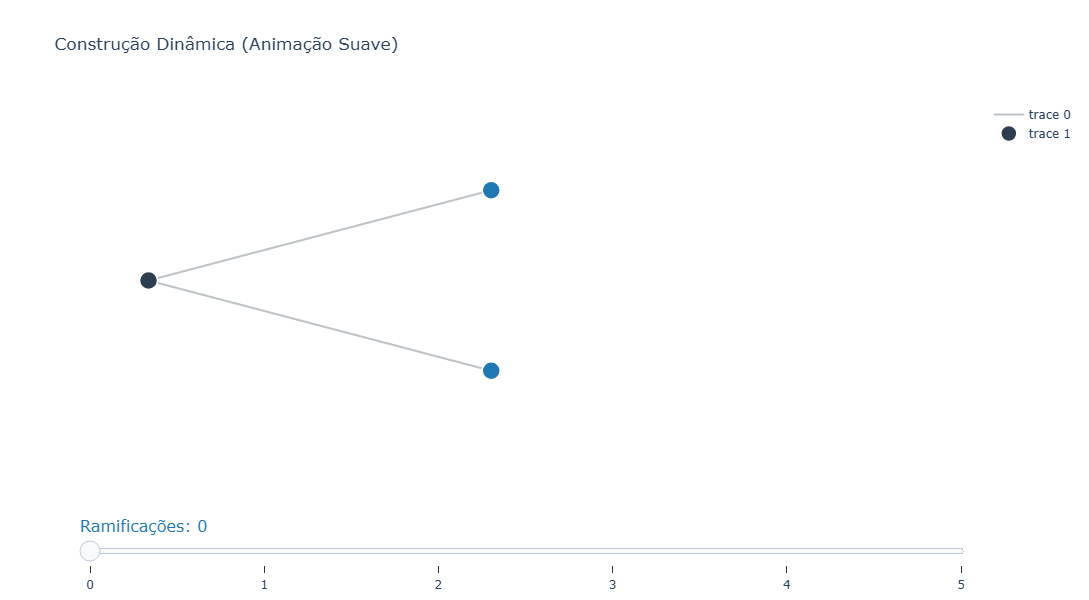

In [5]:
import igraph as ig
import plotly.graph_objects as go

def gerar_dados_reconstrucao(n_fixo, m_slider):
    m_max = 5
    pos_pais = {1: 200, 2: -200}
    
    Xn, Yn = [], []
    Xe, Ye = [], []
    
    # 1. Raiz (Fixa)
    Xn.append(0); Yn.append(0)
    
    # 2. Nível 1 (Fixos)
    Xn.extend([2.5, 2.5])
    Yn.extend([pos_pais[1], pos_pais[2]])
    
    # Linhas Raiz -> Nível 1
    for i in [1, 2]:
        Xe += [0, 2.5, None]; Ye += [0, Yn[i], None]

    # 3. Nível 2 (Reconstrução Dinâmica)
    for p in range(1, n_fixo + 1):
        p_x, p_y = 2.5, pos_pais[p]
        
        desvios = []
        if m_slider > 0:
            espaco_total = 180 
            if m_slider == 1:
                desvios = [0]
            else:
                passo = espaco_total / (m_slider - 1)
                desvios = [ (espaco_total/2) - (i * passo) for i in range(m_slider)]

        for j in range(m_max):
            if j < m_slider:
                target_x = 5.0
                target_y = p_y + desvios[j]
            else:
                # Retorno ao pai para o efeito de "reset"
                target_x = p_x
                target_y = p_y
            
            Xn.append(target_x); Yn.append(target_y)
            Xe += [p_x, target_x, None]; Ye += [p_y, target_y, None]

    colors = ['#2C3E50'] + ['#FF7F0E']*2 + ['#1F77B4']*(n_fixo * m_max)
    
    return Xe, Ye, Xn, Yn, colors

# --- Construção da Figura ---
fig = go.Figure()
frames = []
slider_steps = []

for m in range(6): 
    Xe, Ye, Xn, Yn, colors = gerar_dados_reconstrucao(2, m)
    name = f"m_{m}"
    
    frames.append(go.Frame(
        data=[
            go.Scatter(x=Xe, y=Ye, mode='lines', line=dict(color='#BDC3C7', width=2)),
            go.Scatter(x=Xn, y=Yn, mode='markers', 
                        marker=dict(size=18, color=colors, line=dict(width=1.5, color='white')))
        ],
        name=name
    ))
    
    slider_steps.append({
        "method": "animate",
        "label": str(m),
        "args": [[name], {
            "frame": {"duration": 1600, "redraw": False}, # Tempo total do frame
            "mode": "immediate",
            "transition": {
                "duration": 1500, # VELOCIDADE: 1.5 segundos para desenhar
                "easing": "cubic-in-out" # Começa lento, acelera, termina lento
            }
        }]
    })

# Estado inicial
fig.add_trace(frames[0].data[0])
fig.add_trace(frames[0].data[1])

fig.update_layout(
    title="Construção Dinâmica (Animação Suave)",
    height=600, width=850,
    template="plotly_white",
    xaxis=dict(showgrid=False, zeroline=False, showticklabels=False, range=[-0.5, 6]),
    yaxis=dict(showgrid=False, zeroline=False, showticklabels=False, range=[-400, 400]),
    sliders=[{
        "active": 0,
        "currentvalue": {"prefix": "Ramificações: ", "font": {"size": 16, "color": "#1F77B4"}},
        "pad": {"t": 50},
        "steps": slider_steps
    }]
)

fig.frames = frames
fig.show()

In [2]:
# Você pode alterar os números abaixo para testar outras combinações!
num_lanches = 5
num_sobremesas = 6

# Validando os limites máximos das nossas listas de emojis
if num_lanches > 8:
    print('O número de lanches deve ser menor ou igual a 8.')
    quit()
elif num_sobremesas > 9:
    print('O número de sobremesas deve ser menor ou igual a 9.')
    quit()
else:
    # Gerando a lista de forma automática
    print(f"Gerando cardápios para {num_lanches} lanches e {num_sobremesas} sobremesas:\n")
    
    # Lista com o Unicode e o Nome escrito de cada lanche (Total: 8)
    lanches_emojis = [
        ("\U0001F354", "Hambúrguer"),
        ("\U0001F355", "Pizza"),
        ("\U0001F32D", "Cachorro-Quente"),
        ("\U0001F96A", "Sanduíche"),
        ("\U0001F32E", "Taco"),
        ("\U0001F35F", "Batata Frita"),
        ("\U0001F359", "Bolinho de Arroz"),
        ("\U0001F35D", "Macarrão")
    ]
    
    # Lista com o Unicode e o Nome escrito de cada sobremesa (Total: 9)
    sobremesas_emojis = [
        ("\U0001F366", "Sorvete"),
        ("\U0001F367", "Raspadinha"),
        ("\U0001F369", "Donut"),
        ("\U0001F382", "Bolo"),
        ("\U0001F370", "Fatia de Bolo"),
        ("\U0001F9C1", "Cupcake"),
        ("\U0001F95E", "Panqueca"),
        ("\U0001F36B", "Chocolate"),
        ("\U0001F36A", "Cookie")
    ]
    
    contador = 0
    for l in range(num_lanches):
        lanche_img = lanches_emojis[l][0]
        lanche_nome = lanches_emojis[l][1]
        
        for s in range(num_sobremesas):
            sobremesa_img = sobremesas_emojis[s][0]
            sobremesa_nome = sobremesas_emojis[s][1]
            
            contador += 1
            print(f"Cardápio {contador:02d}: {lanche_img} + {sobremesa_img} -> {lanche_nome} com {sobremesa_nome}")
            
    print(f"\nUfa! O computador encontrou {contador} combinações no total.")

Gerando cardápios para 5 lanches e 6 sobremesas:

Cardápio 01: 🍔 + 🍦 -> Hambúrguer com Sorvete
Cardápio 02: 🍔 + 🍧 -> Hambúrguer com Raspadinha
Cardápio 03: 🍔 + 🍩 -> Hambúrguer com Donut
Cardápio 04: 🍔 + 🎂 -> Hambúrguer com Bolo
Cardápio 05: 🍔 + 🍰 -> Hambúrguer com Fatia de Bolo
Cardápio 06: 🍔 + 🧁 -> Hambúrguer com Cupcake
Cardápio 07: 🍕 + 🍦 -> Pizza com Sorvete
Cardápio 08: 🍕 + 🍧 -> Pizza com Raspadinha
Cardápio 09: 🍕 + 🍩 -> Pizza com Donut
Cardápio 10: 🍕 + 🎂 -> Pizza com Bolo
Cardápio 11: 🍕 + 🍰 -> Pizza com Fatia de Bolo
Cardápio 12: 🍕 + 🧁 -> Pizza com Cupcake
Cardápio 13: 🌭 + 🍦 -> Cachorro-Quente com Sorvete
Cardápio 14: 🌭 + 🍧 -> Cachorro-Quente com Raspadinha
Cardápio 15: 🌭 + 🍩 -> Cachorro-Quente com Donut
Cardápio 16: 🌭 + 🎂 -> Cachorro-Quente com Bolo
Cardápio 17: 🌭 + 🍰 -> Cachorro-Quente com Fatia de Bolo
Cardápio 18: 🌭 + 🧁 -> Cachorro-Quente com Cupcake
Cardápio 19: 🥪 + 🍦 -> Sanduíche com Sorvete
Cardápio 20: 🥪 + 🍧 -> Sanduíche com Raspadinha
Cardápio 21: 🥪 + 🍩 -> Sanduíche com D

```{figure} imagens/diagrama1.png
---
width: 500px
name: fig-arvore1
---
Árvore de possibilidades
```

In [1]:
from jupyterquiz import display_quiz

# Definição da pergunta
pergunta = [{
    "question": "Quantos números de 3 algarismos podem ser formados com os algarismos 1,2,3,4,5?",
    "type": "multiple_choice",
    "answers": [
        {"answer": "15", "correct": False, "feedback": "Não é isso! Pense em quantas escolhas você tem pra cada posição"},
        {"answer": "125", "correct": True, "feedback": "Exato! 5 possibilidades para cada posição! 5x5x5"},
        {"answer": "60", "correct": False, "feedback": "Não é isso! Lembre-se que os algarismos podem se repetir"}
    ]
}]

display_quiz(pergunta)

<IPython.core.display.Javascript object>

In [1]:
import json
from IPython.display import HTML, display

# 1. Você continua gerenciando tudo pelo Python!
# Fica super fácil adicionar ou remover itens no futuro.
lanches = [
    ["🍔", "Hambúrguer"], ["🍕", "Pizza"], ["🌭", "Cachorro-Quente"], 
    ["🥪", "Sanduíche"], ["🌮", "Taco"], ["🍟", "Batata Frita"], 
    ["🍙", "Bolinho de Arroz"], ["🍝", "Macarrão"]
]

sobremesas = [
    ["🍦", "Sorvete"], ["🍧", "Raspadinha"], ["🍩", "Donut"], 
    ["🎂", "Bolo"], ["🍰", "Fatia de Bolo"], ["🧁", "Cupcake"], 
    ["🥞", "Panqueca"], ["🍫", "Chocolate"], ["🍪", "Cookie"]
]

# 2. O Python "traduz" essas listas para um formato que o navegador do aluno entende
lanches_json = json.dumps(lanches)
sobremesas_json = json.dumps(sobremesas)

# 3. O Python monta a interface visual que vai morar dentro do seu Jupyter Book
codigo_interativo = f"""
<div style="font-family: system-ui, sans-serif; max-width: 600px; margin: 20px auto; padding: 20px; border: 1px solid #e1e4e6; border-radius: 8px; background-color: #f8f9fa;">
    <h3 style="margin-top: 0; color: #24292e;">🍽️ Simulador de Cardápios</h3>
    
    <div style="margin-bottom: 15px;">
        <label style="display: inline-block; width: 180px; font-weight: bold;">Lanches Salgados: <span id="valLanches">2</span></label>
        <input type="range" id="slideLanches" min="1" max="8" value="2" style="width: 200px; vertical-align: middle;">
    </div>
    
    <div style="margin-bottom: 20px;">
        <label style="display: inline-block; width: 180px; font-weight: bold;">Sobremesas: <span id="valSobremesas">3</span></label>
        <input type="range" id="slideSobremesas" min="1" max="9" value="3" style="width: 200px; vertical-align: middle;">
    </div>
    
    <div id="calculoHeader" style="font-weight: bold; font-size: 1.1em; color: #0366d6; margin-bottom: 15px; padding-bottom: 10px; border-bottom: 1px solid #e1e4e6;">
        Temos 6 cardápios possíveis.
    </div>
    
    <div id="listaCombinacoes" style="max-height: 250px; overflow-y: auto; background: white; padding: 10px; border: 1px solid #e1e4e6; border-radius: 4px; font-family: monospace; font-size: 0.95em; line-height: 1.6;">
    </div>
</div>

<script>
    // As listas que o Python traduziu entram aqui magicamente!
    const dadosLanches = {lanches_json};
    const dadosSobremesas = {sobremesas_json};

    const sLanches = document.getElementById('slideLanches');
    const sSobremesas = document.getElementById('slideSobremesas');
    const vLanches = document.getElementById('valLanches');
    const vSobremesas = document.getElementById('valSobremesas');
    const header = document.getElementById('calculoHeader');
    const lista = document.getElementById('listaCombinacoes');

    function atualizar() {{
        const nL = parseInt(sLanches.value);
        const nS = parseInt(sSobremesas.value);
        
        vLanches.innerText = nL;
        vSobremesas.innerText = nS;
        header.innerText = `Temos ${{nL * nS}} cardápios possíveis.`;
        
        let htmlStr = "";
        let count = 0;
        
        for (let l = 0; l < nL; l++) {{
            for (let s = 0; s < nS; s++) {{
                count++;
                const countStr = String(count).padStart(2, '0');
                htmlStr += `Cardápio countStr:{{dadosLanches[l][0]}} dadosSobremesas[s][0]−>{{dadosLanches[l][1]}} com ${{dadosSobremesas[s][1]}}<br>`;
            }}
        }}
        lista.innerHTML = htmlStr;
    }}

    sLanches.addEventListener('input', atualizar);
    sSobremesas.addEventListener('input', atualizar);
    atualizar(); // Roda a primeira vez para exibir a lista inicial
</script>
"""

# Exibe o bloco interativo final na célula
display(HTML(codigo_interativo))

In [1]:
# from jupyterquiz import display_quiz

# Definição da pergunta com caixa de texto numérica
pergunta = [{
    "question": "Você vai viajar e está arrumando sua mala. Nela, você colocou 4 calças e 8 camisetas diferentes. Considerando que você precisa escolher uma calça e uma camiseta para formar o 'look' do dia, quantas opções diferentes de conjuntos de roupa você poderá formar?",
    "type": "numeric",
    "answers": [
        {
            "type": "value",
            "value": 32,
            "correct": True,
            "feedback": "Exato! 4x8=32 conjuntos"
        },
        {
            "type": "value",
            "value": 12,
            "correct": False,
            "feedback": "Não é isso! Pense de quantas maneiras você pode fazer cada escolha (multiplicar, e não somar)."
        },
        {
            "type": "default",
            "feedback": "Não é isso! Tente novamente. Pense: quantas opções você tem para a calça? E para a camiseta?"
        }
    ]
}]

display_quiz(pergunta)

NameError: name 'display_quiz' is not defined